# 01 · Dataset analysis — SEM cross-sections, three batches

**Purpose.** Understand the data before designing any QC logic: what was imaged, how consistently it was acquired, which measurable microstructure quantities vary between and within batches, and which artifacts would mislead a naive comparison.

**Scope.** Descriptive only. No baseline is assumed, no verdicts are produced. Everything here feeds the KPI design in the next notebook.

**Data.** `Dataset/Batch_{1,2,3}/img_<site>_<detector>.tif`. Each *site* is one stitched cross-section imaged with three detectors: backscattered electrons (**BSE**, contrast ∝ atomic number), secondary electrons (**ETD**, labelled **SE** on four sites; topography), and the in-column **Inlens** detector (surface-sensitive, strong charging contrast).

In [1]:
import os, re, glob, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tifffile
from scipy import ndimage as ndi, stats
from skimage.filters import threshold_multiotsu, gaussian
from skimage.measure import label, regionprops_table
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 200)

ROOT  = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
DATA  = os.path.join(ROOT, "Dataset")
CACHE = os.path.join(ROOT, "analysis_cache"); os.makedirs(CACHE, exist_ok=True)

BATCHES = ["Batch_1", "Batch_2", "Batch_3"]
COL = {"Batch_1": "#2a78d6", "Batch_2": "#eb6834", "Batch_3": "#1baf7a", "Batch_3 (grey-pore group)": "#eda100"}
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 11, "axes.labelsize": 10,
                     "legend.frameon": False})

# ---- index every file -------------------------------------------------------
rows = []
for f in sorted(glob.glob(os.path.join(DATA, "*", "*.tif"))):
    b = os.path.basename(os.path.dirname(f)); m = re.match(r"img_(\w+)_(\w+)\.tif", os.path.basename(f))
    det = m.group(2); rows.append(dict(batch=b, site=m.group(1), det=det, det_norm={"SE": "ETD"}.get(det, det), path=f, mb=os.path.getsize(f)/1e6))
index = pd.DataFrame(rows)
SITES = index[["batch", "site"]].drop_duplicates().reset_index(drop=True)

def load(batch, site, det="BSE"):
    """Grayscale uint8 image (the TIFFs store identical R,G,B planes)."""
    p = index.query("batch==@batch and site==@site and det_norm==@det").path.iloc[0]
    return tifffile.imread(p)[..., 0]

def bright_bands(img, margin=0.2, delta=40, minrows=4):
    """Rows at the top/bottom that are far brighter than the body (current collector / stitching border)."""
    rm = img.mean(1); body = np.median(rm); H = len(rm)
    hot = rm > body + delta
    top = 0
    while top < H*margin and hot[top]: top += 1
    bot = 0
    while bot < H*margin and hot[H-1-bot]: bot += 1
    # allow a few dark rows before the band (bands are not always flush with the edge)
    idx = np.where(hot)[0]
    if (idx >= H*(1-margin)).any(): bot = max(bot, H - idx[idx >= H*(1-margin)].min())
    if (idx <  H*margin).any():     top = max(top, idx[idx < H*margin].max()+1)
    return (top if top >= minrows else 0), (bot if bot >= minrows else 0)

def trimmed(img):
    t, b = bright_bands(img); return img[t: img.shape[0]-b if b else None]

print(f"{len(index)} files, {len(SITES)} sites, {index.mb.sum():.0f} MB total")

93 files, 31 sites, 1733 MB total


## 1 · Inventory

How many sites per batch, which detectors exist for each, and whether anything is missing.

In [2]:
inv = index.pivot_table(index=["batch","site"], columns="det", values="mb", aggfunc="size").fillna(0).astype(int)
summary = pd.DataFrame({
    "sites": SITES.groupby("batch").size(),
    "files": index.groupby("batch").size(),
    "MB":    index.groupby("batch").mb.sum().round(0),
    "sites with ETD": index[index.det=="ETD"].groupby("batch").site.nunique(),
    "sites with SE (alt. label)": index[index.det=="SE"].groupby("batch").site.nunique(),
}).fillna(0).astype(int)
display(summary)
print("Detector counts per site (1 = present):"); display(inv)
assert (inv.sum(1) == 3).all(), "every site should have exactly three detector images"

,sites,files,MB,sites with ETD,sites with SE (alt. label)
batch,,,,,
Batch_1,7,21,421,7,0
Batch_2,7,21,420,6,1
Batch_3,17,51,892,14,3


Detector counts per site (1 = present):


det               BSE  ETD  Inlens  SE
batch   site                          
Batch_1 4ih2ggld    1    1       1   0
        5n1q8atc    1    1       1   0
        f1vzngrs    1    1       1   0
        ffwubibz    1    1       1   0
        fzrt2k6r    1    1       1   0
        iv6g2oq0    1    1       1   0
        uhdslk0o    1    1       1   0
Batch_2 3806gxp0    1    1       1   0
        avn74qx1    1    1       1   0
        b3esycq1    1    1       1   0
        epqdaau9    1    1       1   0
        i9jiqjwl    1    1       1   0
        r17byphk    1    1       1   0
        rxax5ozo    1    0       1   1
Batch_3 0grcilhi    1    1       1   0
        71vgq3fw    1    1       1   0
        9luzk4jm    1    1       1   0
        cfe5vt7s    1    1       1   0
        hawkfj64    1    1       1   0
        hzumfsms    1    1       1   0
        kbdh4tri    1    1       1   0
        mgxahqnk    1    1       1   0
        pl8uabbv    1    1       1   0
        ptg8lmto    1    1       1   0
        tuy3zymq    1    1       1   0
        ufdvpb81    1    1       1   0
        utfgcjfa    1    0       1   1
        vc2whyaq    1    0       1   1
        x77cy643    1    0       1   1
        x7u69zsw    1    1       1   0
        xgj4xftb    1    1       1   0

Every site has exactly three detector images. The secondary-electron image is labelled `ETD` on 27 sites and `SE` on 4 (one in Batch 2, three in Batch 3). These are the same physical signal and are merged under `ETD` below, but the label change is itself a hint that acquisition sessions differed.

Batch 3 is 2.4× larger than the others. A reference batch is often the largest, but size alone does not make it the baseline.

## 2 · Image geometry

All images are stitched strips ~7000 px wide. Height varies per site. Since each strip spans the full coating cross-section, **height is a proxy for coating thickness** — but only if magnification was constant, which we cannot verify because every acquisition tag was stripped (`Software = tifffile.py`, resolution tags are 1 inch/px placeholders).

,sites,H_min,H_median,H_max,H_cv,W_values
batch,,,,,,
Batch_1,7,1780,2148.0,2316,0.097,"[6960, 6996, 7000]"
Batch_2,7,2048,2080.0,2272,0.038,[7000]
Batch_3,17,1612,2060.0,2272,0.085,"[6996, 7000]"


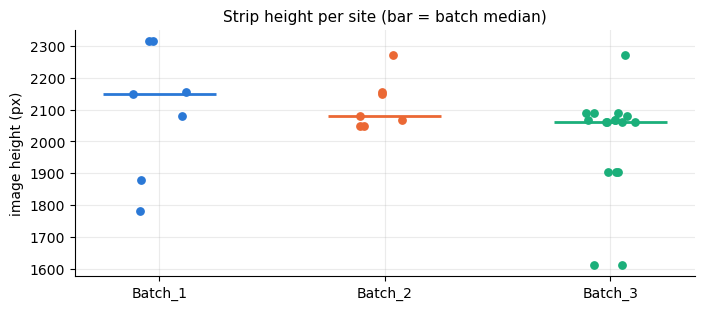

In [3]:
geo = []
for _, r in SITES.iterrows():
    with tifffile.TiffFile(index.query("batch==@r.batch and site==@r.site and det=='BSE'").path.iloc[0]) as t:
        p = t.pages[0]; geo.append(dict(batch=r.batch, site=r.site, H=p.imagelength, W=p.imagewidth, dtype=str(p.dtype), spp=p.samplesperpixel))
geo = pd.DataFrame(geo)
display(geo.groupby("batch").agg(sites=("site","size"), H_min=("H","min"), H_median=("H","median"), H_max=("H","max"), H_cv=("H", lambda x: round(x.std()/x.mean(),3)), W_values=("W", lambda x: sorted(set(x)))))

fig, ax = plt.subplots(figsize=(8, 3.2))
for i, b in enumerate(BATCHES):
    y = geo[geo.batch==b].H.values
    ax.scatter(np.full_like(y, i, dtype=float) + np.random.uniform(-.12,.12,len(y)), y, s=28, color=COL[b], label=b, zorder=3)
    ax.hlines(np.median(y), i-.25, i+.25, color=COL[b], lw=2)
ax.set_xticks(range(3)); ax.set_xticklabels(BATCHES); ax.set_ylabel("image height (px)"); ax.set_title("Strip height per site (bar = batch median)")
plt.show()

Median heights are similar across batches (~2060–2150 px) and the spread within a batch (CV 4–10 %) is as large as any difference between batches, so height carries no batch signal. Several exact heights recur across *different* batches (2080, 2148, 2156, 2272) and four Batch 3 sites share 2060 px while two Batch 1 sites share 2316 px. Repeated heights are more plausibly an acquisition-session fingerprint (same crop/stage settings) than coincidental equal thickness, which is why we treat height as a session indicator as much as a thickness proxy.

## 3 · What the images look like

One site per batch, all three detectors, plus a 1600×800 px full-resolution crop.

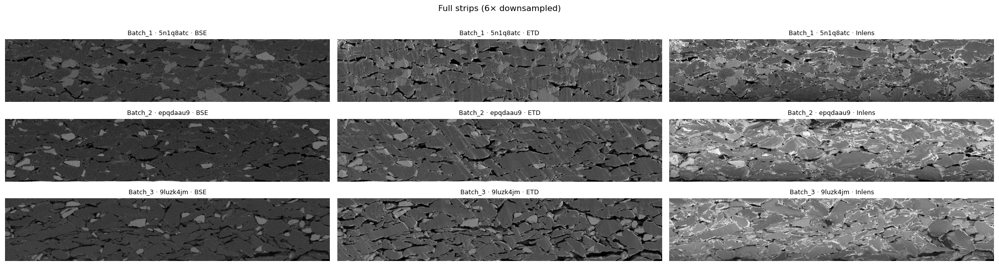

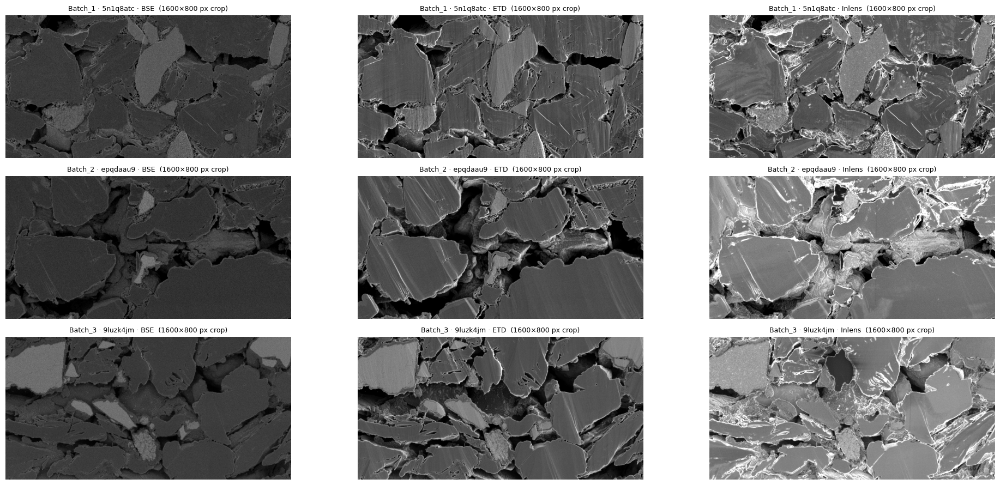

In [4]:
picks = [("Batch_1","5n1q8atc"), ("Batch_2","epqdaau9"), ("Batch_3","9luzk4jm")]
fig, axes = plt.subplots(3, 3, figsize=(20, 5.2))
for i, (b, s) in enumerate(picks):
    for j, d in enumerate(["BSE","ETD","Inlens"]):
        axes[i,j].imshow(load(b,s,d)[::6, ::6], cmap="gray", vmin=0, vmax=255, aspect="auto"); axes[i,j].axis("off"); axes[i,j].set_title(f"{b} · {s} · {d}", fontsize=9)
plt.suptitle("Full strips (6× downsampled)", y=1.01); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 3, figsize=(20, 9))
for i, (b, s) in enumerate(picks):
    for j, d in enumerate(["BSE","ETD","Inlens"]):
        a = load(b,s,d); h, w = a.shape; cy, cx = h//2, w//2
        axes[i,j].imshow(a[cy-400:cy+400, cx-800:cx+800], cmap="gray", vmin=0, vmax=255); axes[i,j].axis("off"); axes[i,j].set_title(f"{b} · {s} · {d}  (1600×800 px crop)", fontsize=9)
plt.tight_layout(); plt.show()

**Reading the images.** Ion-polished cross-sections of a porous electrode coating. The bulk phase is plate-like graphite (medium grey in BSE, with polishing striations in ETD). Scattered particles appear distinctly brighter in BSE, i.e. higher mean atomic number than carbon — consistent with silicon / silicon-oxide additive in a Si–graphite anode, though the chemistry is not confirmed. Black regions in BSE are open pores. Fine "spongy" texture between particles is the conductive-carbon/binder network.

The three detectors carry different information:
- **BSE** separates pore / graphite / bright phase by composition → the channel for phase fractions and particle sizes.
- **ETD** shows topography and polishing relief → edges, cracks, delamination.
- **Inlens** is dominated by charging and surface contamination; its brightness swings wildly between sites → texture only, never intensity.

## 4 · Acquisition quality: histograms, contrast stretching, black level

Before trusting any intensity-derived feature, check whether images were acquired and processed consistently. Three diagnostics per image:
- `gray_levels` / `empty_bin_frac`: a comb-shaped histogram (many empty bins between p1 and p99) means a contrast stretch was applied after acquisition.
- `p1`: the 1st percentile. In BSE of a porous electrode, open pores should be essentially black (p1 ≈ 0). A raised p1 means either pores are filled (resin) or the detector black level/brightness was offset.
- top/bottom bright bands: copper current collector or stitching borders inside the frame.

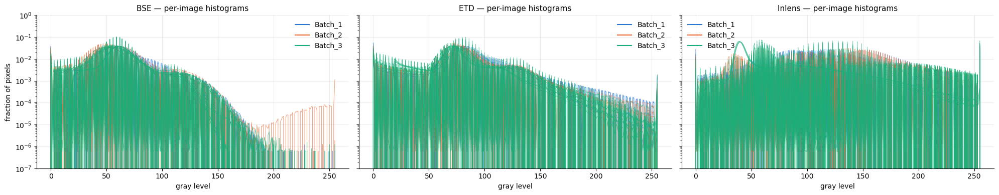

images  mean_gray  mean_sd  p1_median  stretched  raised_black
det    batch                                                                  
BSE    Batch_1       7       58.5      2.4        0.0          0             0
       Batch_2       7       55.2      4.4        0.0          3             0
       Batch_3      17       58.8      3.6        3.0          3             4
ETD    Batch_1       7       80.0      3.0        0.0          2             0
       Batch_2       7       76.7      3.3        0.0          1             0
       Batch_3      17       74.0      3.8        0.0          4             0
Inlens Batch_1       7      117.2     18.7        0.0          6             0
       Batch_2       7      122.6     17.0        2.0          6             0
       Batch_3      17      105.3     23.3       15.0         11             0

In [5]:
qpath = os.path.join(CACHE, "image_quality.csv")
if os.path.exists(qpath):
    Q = pd.read_csv(qpath)
else:
    rows = []
    for _, r in index.iterrows():
        a = tifffile.imread(r.path)[..., 0]
        lo, hi = np.percentile(a, [1, 99]).astype(int)
        h = np.bincount(a.ravel()[::3], minlength=256)
        t, bo = bright_bands(a)
        rows.append(dict(batch=r.batch, site=r.site, det=r.det_norm, H=a.shape[0], mean=a.mean(), p1=lo, p50=np.median(a), p99=hi, std=a.std(),
                         gray_levels=int((h > 0).sum()), empty_bin_frac=(h[lo:hi+1] == 0).mean(), band_top=t, band_bottom=bo))
    Q = pd.DataFrame(rows); Q.to_csv(qpath, index=False)
Q["contrast_stretched"] = Q.empty_bin_frac > 0.2
Q["raised_black_level"] = (Q.det == "BSE") & (Q.p1 > 10)

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=True)
for ax, d in zip(axes, ["BSE","ETD","Inlens"]):
    for _, r in index[index.det_norm == d].iterrows():
        a = tifffile.imread(r.path)[..., 0]
        h = np.bincount(a.ravel()[::9], minlength=256) / (a.size/9)
        ax.plot(np.arange(256), h, color=COL[r.batch], lw=0.8, alpha=0.6)
    ax.set_yscale("log"); ax.set_ylim(1e-7, 1); ax.set_title(f"{d} — per-image histograms"); ax.set_xlabel("gray level")
    for b in BATCHES: ax.plot([], [], color=COL[b], label=b)
    ax.legend()
axes[0].set_ylabel("fraction of pixels")
plt.tight_layout(); plt.show()

display(Q.groupby(["det","batch"]).agg(images=("site","size"), mean_gray=("mean","mean"), mean_sd=("mean","std"), p1_median=("p1","median"),
                                      stretched=("contrast_stretched","sum"), raised_black=("raised_black_level","sum")).round(1))

In [6]:
bse = Q[Q.det=="BSE"].sort_values(["batch","p1","mean"])
display(bse[["batch","site","H","mean","p1","p50","p99","gray_levels","empty_bin_frac","contrast_stretched","raised_black_level"]].round(2).reset_index(drop=True))
GREY_PORE = sorted(bse[bse.raised_black_level].site.tolist()); print("BSE images with raised black level (p1 > 10):", GREY_PORE)

,batch,site,H,mean,p1,p50,p99,gray_levels,empty_bin_frac,contrast_stretched,raised_black_level
0,Batch_1,f1vzngrs,2148,54.38,0,52.0,131,190,0.07,False,False
1,Batch_1,iv6g2oq0,1780,57.29,0,57.0,135,169,0.13,False,False
2,Batch_1,4ih2ggld,2316,57.39,0,57.0,116,154,0.19,False,False
3,Batch_1,ffwubibz,2080,58.69,0,59.0,128,177,0.03,False,False
4,Batch_1,5n1q8atc,2316,59.72,0,59.0,119,167,0.16,False,False
5,Batch_1,uhdslk0o,1880,60.17,0,60.0,133,175,0.05,False,False
6,Batch_1,fzrt2k6r,2156,61.58,0,62.0,131,165,0.06,False,False
7,Batch_2,avn74qx1,2048,49.58,0,49.0,123,164,0.06,False,False
8,Batch_2,3806gxp0,2048,51.11,0,49.0,127,152,0.21,True,False
9,Batch_2,epqdaau9,2148,53.80,0,52.0,133,218,0.07,False,False


BSE images with raised black level (p1 > 10): ['71vgq3fw', 'kbdh4tri', 'tuy3zymq', 'x7u69zsw']


Two acquisition findings:

1. **Contrast stretching is widespread and uneven.** About half of all images have comb histograms; Inlens almost always, BSE in roughly a third of sites, with up to 65 % of gray levels empty (`9luzk4jm`, `hzumfsms`). Absolute gray values are therefore not comparable across sites even within one batch. Any KPI built on raw intensity measures the operator's display settings as much as the material.
2. **Four Batch 3 sites have no black pixels in BSE** (`p1 ≈ 24` vs 0 everywhere else) and are the only images with *no* contrast stretching. Their histograms are a different shape, not a shifted copy. These are the same four sites with identical 2060 px height. Either their pores are filled with a grey phase (resin infiltration) or they were recorded in a different session with a different black level. We call them the **grey-pore group** and track them separately from here on.

## 5 · Frame-edge artifacts

Bright bands at the top or bottom of a strip are copper current collector or stitching borders. They would inflate the bright-phase fraction if left in.

,batch,site,det,H,band_top,band_bottom
0,Batch_2,epqdaau9,BSE,2148,0,15
1,Batch_2,epqdaau9,ETD,2148,0,11
2,Batch_2,i9jiqjwl,ETD,2272,49,0
3,Batch_2,i9jiqjwl,Inlens,2272,6,0
4,Batch_3,cfe5vt7s,Inlens,2080,56,0


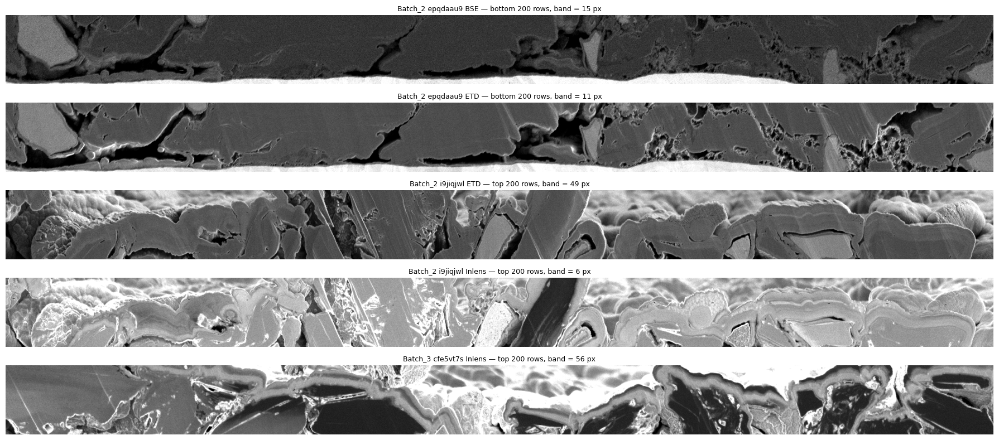

In [7]:
bands = Q[(Q.band_top > 0) | (Q.band_bottom > 0)][["batch","site","det","H","band_top","band_bottom"]]
display(bands.reset_index(drop=True))
fig, axes = plt.subplots(len(bands), 1, figsize=(18, 1.6*len(bands)))
for ax, (_, r) in zip(np.atleast_1d(axes), bands.iterrows()):
    a = load(r.batch, r.site, r.det)
    strip = a[-200:, 1000:4500] if r.band_bottom else a[:200, 1000:4500]
    ax.imshow(strip, cmap="gray", vmin=0, vmax=255, aspect="auto"); ax.axis("off")
    ax.set_title(f"{r.batch} {r.site} {r.det} — {'bottom' if r.band_bottom else 'top'} 200 rows, band = {max(r.band_top, r.band_bottom)} px", fontsize=9)
plt.tight_layout(); plt.show()

Only a handful of images are affected and the bands are thin (≤ 56 rows of ~2000). Trimming them is cheap insurance; the segmentation below does so.

## 6 · Phase segmentation on BSE: pore / graphite / bright phase

Thresholds are set per image from the smoothed BSE histogram, anchored on the graphite mode (the dominant peak). Where a second, brighter mode is resolved, the bright-phase threshold is the valley between the two modes — the most defensible choice. Where no second mode exists, the threshold falls back to *graphite mode + 3.5 σ* and the image is flagged `bright_mode_resolved = False`. The same logic sets the pore threshold on the dark side. (A plain multi-Otsu was tried first and placed the upper threshold inside the graphite peak on low-contrast images, inflating the bright fraction 3×; that failure is documented in §4b below.)

This gives the first set of candidate material KPIs:

| KPI | Meaning for the material |
|---|---|
| `pore_frac` | area fraction of open porosity — electrolyte access, calendering density |
| `bright_frac` | area fraction of the high-Z additive (Si / SiOx) — formulation loading |
| `bright_count_per_Mpx`, `bright_d10/d50/d90` | number density and size distribution of additive particles (px units) — supplier powder PSD, agglomeration |
| `bright_circ` | mean circularity of additive particles — fractured vs intact |
| `pore_d50`, `pore_elong` | pore size and elongation — crack-like vs equiaxed porosity |
| `profile_*` | pore and bright fraction in 10 depth bins — through-thickness gradients (binder migration, additive settling) |
| `fft_slope`, `corr_len_px` | radial power-spectrum slope (edge sharpness / fine texture) and autocorrelation 1/e length (px) — scale-free texture descriptors independent of the segmentation |

In [8]:
fpath = os.path.join(CACHE, "site_features.csv"); ppath = os.path.join(CACHE, "bright_particles.csv"); spath = os.path.join(CACHE, "fft_spectra.npz")

from scipy.signal import find_peaks

def phase_thresholds(sm):
    """Per-image pore/graphite/bright thresholds anchored on the graphite mode of a smoothed BSE histogram.
    Bright threshold = valley between graphite mode and a resolved second (bright) mode when one exists,
    otherwise graphite mode + 3.5 sigma_right (and the image is flagged as 'bright mode not resolved').
    Pore threshold   = valley between the dark mode and graphite mode when one exists, otherwise mode - 3.5 sigma_left."""
    h = np.bincount(sm[::3, ::3].astype(int).ravel(), minlength=256).astype(float); hs = ndi.gaussian_filter1d(h, 3) + 1e-9
    m = int(np.argmax(hs[10:200])) + 10; half = hs[m] / 2
    l = m
    while l > 0 and hs[l] > half: l -= 1
    r = m
    while r < 255 and hs[r] > half: r += 1
    sl, sr = (m - l) / 1.177, (r - m) / 1.177
    # bright side
    pk, _ = find_peaks(np.log(hs[m+15:220]), prominence=0.4); pk = pk + m + 15
    if len(pk):
        p2 = int(pk[np.argmax(hs[pk])]); thi = int(m + np.argmin(hs[m:p2])); bright_resolved = True
    else:
        p2 = np.nan; thi = m + 3.5 * sr; bright_resolved = False
    bright_sep = p2 - m if bright_resolved else np.nan          # contrast between bright phase and graphite, in gray levels
    bright_low_contrast = (not bright_resolved) or (bright_sep < 45)
    # dark side
    pkl, _ = find_peaks(np.log(hs[:max(m-10, 1)]), prominence=0.4)
    if len(pkl) or hs[0] > hs[max(m-10,1):m].min():
        dark_peak = pkl[np.argmax(hs[pkl])] if len(pkl) else 0
        tlo = int(dark_peak + np.argmin(hs[dark_peak:m])); pore_resolved = True
    else:
        tlo = m - 3.5 * sl; pore_resolved = False
    return dict(th_lo=tlo, th_hi=thi, graphite_mode=m, sigma_l=sl, sigma_r=sr, bright_mode=p2, bright_sep=bright_sep,
                bright_mode_resolved=bright_resolved, bright_low_contrast=bright_low_contrast, pore_mode_resolved=pore_resolved, hist=hs/hs.sum())

def corr_length(img, n=16, size=512, seed=0):
    """1/e decay length (px) of the radially averaged autocorrelation of BSE texture."""
    rng = np.random.default_rng(seed); H, W = img.shape; acc = np.zeros(size//2)
    y, x = np.indices((size, size)); rr = np.hypot(y-size/2, x-size/2).astype(int)
    for _ in range(n):
        r0, c0 = rng.integers(0, H-size), rng.integers(0, W-size); p = img[r0:r0+size, c0:c0+size].astype(float); p -= p.mean()
        Fp = np.fft.fft2(p); ac = np.fft.fftshift(np.real(np.fft.ifft2(Fp*np.conj(Fp)))); ac /= ac.max()
        acc += (np.bincount(rr.ravel(), ac.ravel()) / np.maximum(np.bincount(rr.ravel()), 1))[:size//2]
    acc /= n; idx = np.where(acc < np.exp(-1))[0]
    return float(idx[0]) if len(idx) else np.nan

def radial_psd(img, n=24, size=512, seed=0):
    rng = np.random.default_rng(seed); H, W = img.shape
    acc = None
    y, x = np.indices((size, size)); r = np.hypot(y-size/2, x-size/2).astype(int)
    for _ in range(n):
        r0, c0 = rng.integers(0, H-size), rng.integers(0, W-size)
        p = img[r0:r0+size, c0:c0+size].astype(float); p -= p.mean(); p /= (p.std()+1e-9)
        P = np.abs(np.fft.fftshift(np.fft.fft2(p*np.hanning(size)[:,None]*np.hanning(size)[None,:])))**2
        rad = np.bincount(r.ravel(), P.ravel()) / np.maximum(np.bincount(r.ravel()), 1)
        acc = rad if acc is None else acc + rad
    return acc[1:size//2] / n

hpath = os.path.join(CACHE, "bse_histograms.npz")
if os.path.exists(fpath):
    F = pd.read_csv(fpath); P = pd.read_csv(ppath); SPEC = dict(np.load(spath)); HIST = dict(np.load(hpath))
else:
    feats, parts, SPEC, HIST = [], [], {}, {}
    for _, r in SITES.iterrows():
        a = trimmed(load(r.batch, r.site, "BSE")); H, W = a.shape
        sm = gaussian(a, sigma=1.0, preserve_range=True)
        th = phase_thresholds(sm); HIST[f"{r.batch}/{r.site}"] = th.pop("hist")
        pore, bright = sm < th["th_lo"], sm > th["th_hi"]
        pore = ndi.binary_opening(pore, iterations=1); bright = ndi.binary_opening(bright, iterations=1)
        f = dict(batch=r.batch, site=r.site, H=H, W=W, **th, pore_frac=pore.mean(), bright_frac=bright.mean(), graphite_frac=1-pore.mean()-bright.mean())
        # bright-phase particles
        lab = label(bright); rp = pd.DataFrame(regionprops_table(lab, properties=("area","equivalent_diameter_area","eccentricity","solidity","perimeter","major_axis_length","minor_axis_length")))
        rp = rp[rp.area >= 50]; rp["circ"] = 4*np.pi*rp.area/np.maximum(rp.perimeter,1)**2; rp["batch"], rp["site"] = r.batch, r.site
        parts.append(rp)
        d = rp.equivalent_diameter_area.values; wts = rp.area.values  # area-weighted PSD, like a laser-diffraction D-values
        order = np.argsort(d); cw = np.cumsum(wts[order])/wts.sum()
        f.update(bright_count_per_Mpx=len(rp)/(H*W/1e6), bright_d10=d[order][np.searchsorted(cw,.1)], bright_d50=d[order][np.searchsorted(cw,.5)], bright_d90=d[order][np.searchsorted(cw,.9)],
                 bright_circ=np.average(rp.circ, weights=wts), bright_solidity=np.average(rp.solidity, weights=wts), bright_max_d=d.max())
        # pores
        labp = label(pore); pp = pd.DataFrame(regionprops_table(labp, properties=("area","equivalent_diameter_area","major_axis_length","minor_axis_length"))); pp = pp[pp.area >= 30]
        dp, wp = pp.equivalent_diameter_area.values, pp.area.values; o = np.argsort(dp); cwp = np.cumsum(wp[o])/wp.sum()
        big = pp.major_axis_length > 500   # crack-like voids: long axis > 500 px (~¼ of the coating thickness)
        f.update(pore_count_per_Mpx=len(pp)/(H*W/1e6), pore_d50=dp[o][np.searchsorted(cwp,.5)], pore_d90=dp[o][np.searchsorted(cwp,.9)],
                 pore_elong=np.average(pp.major_axis_length/np.maximum(pp.minor_axis_length,1), weights=wp),
                 pore_max_d=dp.max(), crack_frac=pp.area[big].sum()/(H*W), crack_count_per_Mpx=big.sum()/(H*W/1e6))
        # through-thickness profiles (10 bins, top = separator side? unknown; keep image orientation)
        for k, (lo, hi) in enumerate(zip(np.linspace(0,H,11)[:-1].astype(int), np.linspace(0,H,11)[1:].astype(int))):
            f[f"profile_pore_{k}"] = pore[lo:hi].mean(); f[f"profile_bright_{k}"] = bright[lo:hi].mean()
        # texture scale
        spec = radial_psd(a); SPEC[f"{r.batch}/{r.site}"] = spec
        k = np.arange(1, len(spec)+1); sl = slice(4, 120)
        f["fft_slope"] = np.polyfit(np.log(k[sl]), np.log(spec[sl]), 1)[0]; f["corr_len_px"] = corr_length(a)
        feats.append(f); print(f"{r.batch} {r.site}: thr {f['th_lo']:.0f}/{f['th_hi']:.0f} bright sep {f['bright_sep']} low-contrast={f['bright_low_contrast']} | pore {f['pore_frac']:.3f} bright {f['bright_frac']:.3f} d50 {f['bright_d50']:.0f}px crack {f['crack_frac']:.4f} corr {f['corr_len_px']:.0f}px", flush=True)
    F = pd.DataFrame(feats); P = pd.concat(parts, ignore_index=True)
    F.to_csv(fpath, index=False); P.to_csv(ppath, index=False); np.savez(spath, **SPEC); np.savez(hpath, **HIST)
F["group"] = np.where(F.site.isin(GREY_PORE), "Batch_3 (grey-pore group)", F.batch)
groups = BATCHES + ["Batch_3 (grey-pore group)"]
print(F.shape, "sites × features")

(31, 54) sites × features


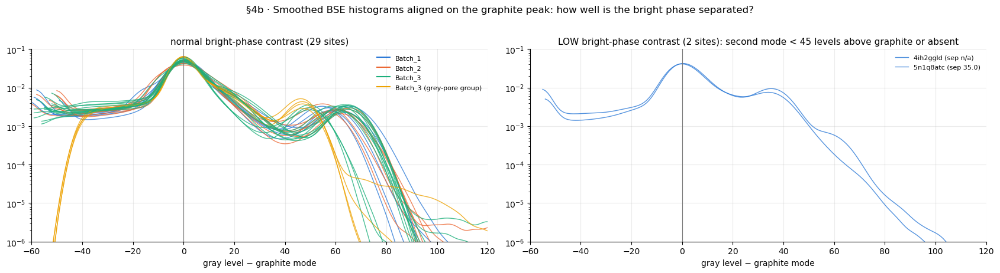

Bright-phase separation (bright mode − graphite mode, gray levels) per group:


,count,min,50%,max
group,,,,
Batch_1,6.0,35.0,58.0,65.0
Batch_2,7.0,55.0,61.0,66.0
Batch_3,13.0,49.0,63.0,65.0
Batch_3 (grey-pore group),4.0,46.0,47.0,47.0


Low-contrast sites: ['4ih2ggld', '5n1q8atc']


,batch,site,H,graphite_mode,bright_mode,bright_sep,th_lo,th_hi,bright_frac,bright_count_per_Mpx
0,Batch_1,4ih2ggld,2316,55,NaN,NaN,34.184,81.763,0.123,125.164
1,Batch_1,5n1q8atc,2316,54,89.0,35.0,33.184,78.000,0.170,133.666


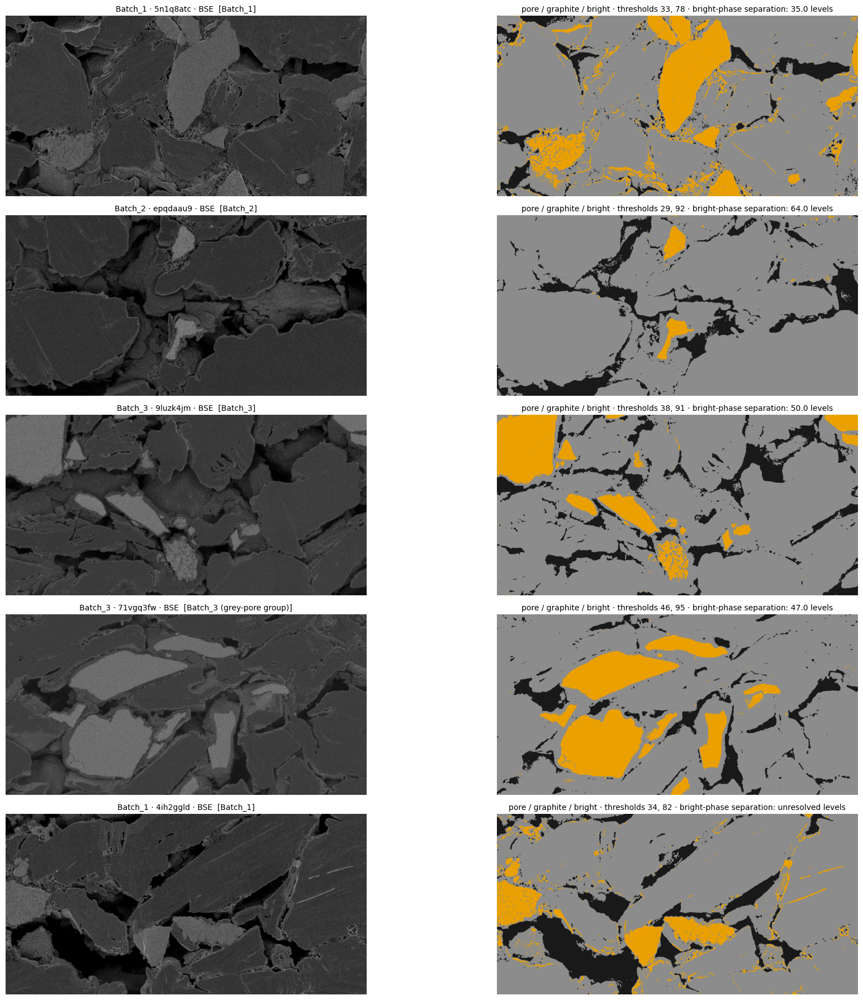

In [9]:
# §4b (placed here because it needs the per-image histograms): BSE histogram shapes aligned on the graphite mode
fig, axes = plt.subplots(1, 2, figsize=(17, 4.5))
for _, r in F.iterrows():
    hs = HIST[f"{r.batch}/{r.site}"]; x = np.arange(256) - r.graphite_mode
    ax = axes[1] if r.bright_low_contrast else axes[0]
    ax.plot(x, hs, color=COL[r.group], lw=1, alpha=.8, label=f"{r.site} (sep {r.bright_sep if r.bright_mode_resolved else 'n/a'})" if r.bright_low_contrast else None)
for ax, t in zip(axes, [f"normal bright-phase contrast ({int((~F.bright_low_contrast).sum())} sites)", f"LOW bright-phase contrast ({int(F.bright_low_contrast.sum())} sites): second mode < 45 levels above graphite or absent"]):
    ax.set_yscale("log"); ax.set_ylim(1e-6, .1); ax.set_xlim(-60, 120); ax.set_xlabel("gray level − graphite mode"); ax.set_title(t); ax.axvline(0, color="#777", lw=.8)
for g in groups: axes[0].plot([], [], color=COL[g], label=g)
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.suptitle("§4b · Smoothed BSE histograms aligned on the graphite peak: how well is the bright phase separated?", y=1.02); plt.tight_layout(); plt.show()
print("Bright-phase separation (bright mode − graphite mode, gray levels) per group:")
display(F.groupby("group").bright_sep.describe()[["count","min","50%","max"]].round(0))
LOW_CONTRAST = sorted(F[F.bright_low_contrast].site.tolist()); print("Low-contrast sites:", LOW_CONTRAST)
display(F[F.bright_low_contrast][["batch","site","H","graphite_mode","bright_mode","bright_sep","th_lo","th_hi","bright_frac","bright_count_per_Mpx"]].round(3).reset_index(drop=True))

# segmentation overlays: one site per batch + one grey-pore site + one low-contrast site
show = picks + [("Batch_3", GREY_PORE[0])] + ([tuple(F[F.bright_low_contrast][["batch","site"]].iloc[0])] if F.bright_low_contrast.any() else [])
fig, axes = plt.subplots(len(show), 2, figsize=(20, 3.6*len(show)))
for i, (b, s) in enumerate(show):
    a = trimmed(load(b, s, "BSE")); h, w = a.shape; cy, cx = h//2, w//2; crop = a[cy-350:cy+350, cx-700:cx+700]
    r = F[(F.batch==b)&(F.site==s)].iloc[0]; sm = gaussian(crop, sigma=1.0, preserve_range=True)
    seg = np.zeros(crop.shape+(3,), float); seg[sm < r.th_lo] = (0.1,0.1,0.1); seg[(sm>=r.th_lo)&(sm<=r.th_hi)] = (0.55,0.55,0.55); seg[sm > r.th_hi] = (0.92,0.63,0.0)
    axes[i,0].imshow(crop, cmap="gray", vmin=0, vmax=255); axes[i,0].set_title(f"{b} · {s} · BSE  [{r.group}]", fontsize=10)
    axes[i,1].imshow(seg); axes[i,1].set_title(f"pore / graphite / bright · thresholds {r.th_lo:.0f}, {r.th_hi:.0f} · bright-phase separation: {r.bright_sep if r.bright_mode_resolved else 'unresolved'} levels", fontsize=10)
    for ax in axes[i]: ax.axis("off")
plt.tight_layout(); plt.show()

The segmentation is clean wherever the bright phase is a well-separated mode (29 of 31 sites, separation 50–70 gray levels above graphite). Two kinds of site need care:
- **Low bright-phase contrast** (red rings in the KPI plots): on two Batch 1 sites the bright phase sits only ~25–35 levels above graphite, on the shoulder of the graphite peak. Any threshold there also picks up particle rims and the binder network, so their bright-phase fraction and particle count are inflated 2–8×. These two sites share an identical frame height (2316 px) that no other site has, which points to a separate acquisition session with different detector contrast rather than a different material. Their bright-phase KPIs must be shown as uncertain, not silently averaged in.
- **Grey-pore group**: the dark side has a broad plateau rather than a black mode, so the pore threshold falls back to *mode − 3.5 σ* and pore KPIs are not directly comparable with the rest.

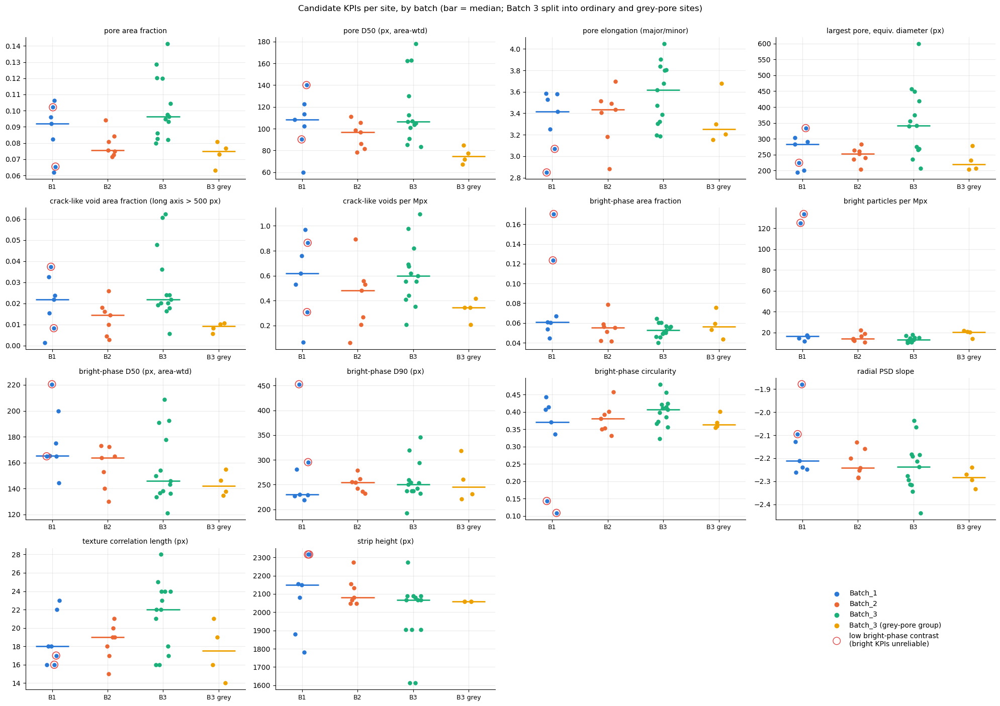

group                         Batch_1   Batch_2   Batch_3  Batch_3 (grey-pore group)
pore_frac            median     0.092     0.075     0.096                      0.075
                     std        0.017     0.008     0.020                      0.008
pore_d50             median   108.254    96.732   106.726                     74.731
                     std       25.458    12.406    31.155                      7.606
pore_elong           median     3.418     3.434     3.618                      3.250
                     std        0.283     0.265     0.288                      0.238
pore_max_d           median   282.665   253.587   341.230                    219.749
                     std       54.675    25.138   108.786                     34.212
crack_frac           median     0.022     0.015     0.022                      0.009
                     std        0.013     0.008     0.018                      0.002
crack_count_per_Mpx  median     0.618     0.484     0.600                      0.347
                     std        0.318     0.275     0.246                      0.087
bright_frac          median     0.061     0.055     0.053                      0.056
                     std        0.046     0.013     0.007                      0.013
bright_count_per_Mpx median    16.560    13.998    12.999                     20.562
                     std       55.769     4.085     2.341                      3.409
bright_d50           median   165.314   163.825   145.727                    142.047
                     std       25.547    16.403    27.274                      9.107
bright_d90           median   230.344   254.451   250.404                    245.451
                     std       83.309    16.221    39.937                     43.903
bright_circ          median     0.370     0.380     0.407                      0.364
                     std        0.136     0.042     0.042                      0.021
fft_slope            median    -2.211    -2.242    -2.238                     -2.282
                     std        0.136     0.061     0.110                      0.040
corr_len_px          median    18.000    19.000    22.000                     17.500
                     std        2.820     1.988     3.755                      3.109
H                    median  2148.000  2080.000  2068.000                   2060.000
                     std      204.071    80.691   191.843                      0.000

In [10]:
kpis = ["pore_frac","pore_d50","pore_elong","pore_max_d","crack_frac","crack_count_per_Mpx",
        "bright_frac","bright_count_per_Mpx","bright_d50","bright_d90","bright_circ",
        "fft_slope","corr_len_px","H"]
labels = {"pore_frac":"pore area fraction","pore_d50":"pore D50 (px, area-wtd)","pore_elong":"pore elongation (major/minor)","pore_max_d":"largest pore, equiv. diameter (px)",
          "crack_frac":"crack-like void area fraction (long axis > 500 px)","crack_count_per_Mpx":"crack-like voids per Mpx",
          "bright_frac":"bright-phase area fraction","bright_count_per_Mpx":"bright particles per Mpx","bright_d50":"bright-phase D50 (px, area-wtd)",
          "bright_d90":"bright-phase D90 (px)","bright_circ":"bright-phase circularity",
          "fft_slope":"radial PSD slope","corr_len_px":"texture correlation length (px)","H":"strip height (px)"}
np.random.seed(0)
fig, axes = plt.subplots(4, 4, figsize=(20, 14)); axes = axes.ravel()
for ax, k in zip(axes, kpis):
    for i, g in enumerate(groups):
        sub = F[F.group==g]
        y = sub[k].values; x = np.full(len(y), i, float) + np.random.uniform(-.14,.14,len(y))
        ax.scatter(x, y, s=26, color=COL[g], zorder=3); ax.hlines(np.median(y), i-.3, i+.3, color=COL[g], lw=2)
        lc = sub.bright_low_contrast.values
        if lc.any(): ax.scatter(x[lc], y[lc], s=110, facecolors="none", edgecolors="#e34948", lw=1.2, zorder=4)
    ax.set_xticks(range(len(groups))); ax.set_xticklabels(["B1","B2","B3","B3 grey"], fontsize=9); ax.set_title(labels[k], fontsize=10)
for ax in axes[len(kpis):]: ax.axis("off")
for g in groups: axes[-1].scatter([], [], color=COL[g], label=g)
axes[-1].scatter([], [], s=110, facecolors="none", edgecolors="#e34948", label="low bright-phase contrast\n(bright KPIs unreliable)")
axes[-1].legend(loc="center", fontsize=10)
plt.suptitle("Candidate KPIs per site, by batch (bar = median; Batch 3 split into ordinary and grey-pore sites)", y=1.0); plt.tight_layout(); plt.show()

tab = F.groupby("group")[kpis].agg(["median", "std"]).round(3)
display(tab.T)

### 6b · Crack-like voids

The pore-structure KPIs single out a few sites with unusually large, elongated voids. Below: the three sites with the largest `crack_frac` and the three with the smallest, full strips at 6× downsampling, with voids whose long axis exceeds 500 px painted red. This is the most defect-like feature in the dataset and the kind of thing a materials engineer would want shown, not scored.

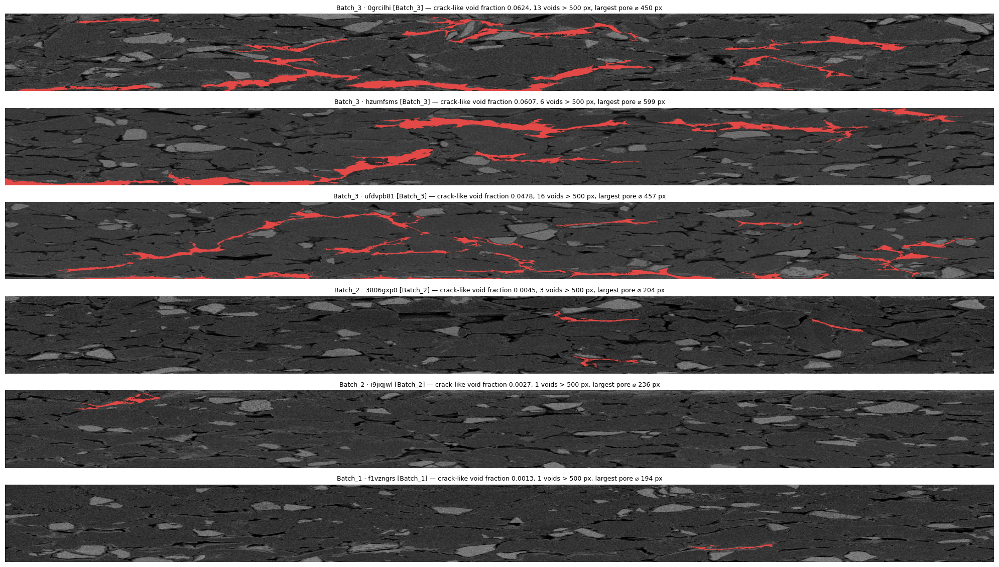

In [11]:
top = F.sort_values("crack_frac", ascending=False); show = list(top.head(3)[["batch","site"]].itertuples(index=False, name=None)) + list(top.tail(3)[["batch","site"]].itertuples(index=False, name=None))
fig, axes = plt.subplots(len(show), 1, figsize=(20, 1.9*len(show)))
for ax, (b, s) in zip(axes, show):
    a = trimmed(load(b, s, "BSE")); r = F[(F.batch==b)&(F.site==s)].iloc[0]
    sm = gaussian(a, 1.0, preserve_range=True); pore = ndi.binary_opening(sm < r.th_lo, iterations=1)
    lab = label(pore); rp = pd.DataFrame(regionprops_table(lab, properties=("label","major_axis_length")))
    bigmask = np.isin(lab, rp.label[rp.major_axis_length > 500].values)
    rgb = np.stack([a]*3, -1).astype(float)/255; rgb[bigmask] = (0.89, 0.29, 0.28)
    ax.imshow(rgb[::6, ::6], aspect="auto"); ax.axis("off")
    ax.set_title(f"{b} · {s} [{r.group}] — crack-like void fraction {r.crack_frac:.4f}, {int(round(r.crack_count_per_Mpx*(r.H*r.W/1e6)))} voids > 500 px, largest pore ⌀ {r.pore_max_d:.0f} px", fontsize=9)
plt.tight_layout(); plt.show()

## 7 · Bright-phase particle size distribution

Area-weighted cumulative distributions of equivalent diameter, pooled per group, plus per-site D50 against number density. The two low-contrast sites are excluded here because their "bright" class is contaminated. Units are pixels; without a scale bar only *relative* shifts are meaningful.

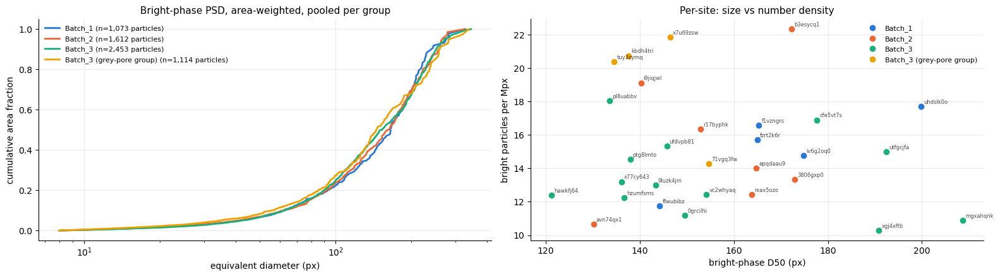

In [12]:
P["group"] = np.where(P.site.isin(GREY_PORE), "Batch_3 (grey-pore group)", P.batch)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for g in groups:
    sub = P[(P.group==g) & ~P.site.isin(LOW_CONTRAST)]
    d = np.sort(sub.equivalent_diameter_area.values); w = sub.area.values[np.argsort(sub.equivalent_diameter_area.values)]
    axes[0].plot(d, np.cumsum(w)/w.sum(), color=COL[g], lw=2, label=f"{g} (n={len(d):,} particles)")
axes[0].set_xscale("log"); axes[0].set_xlabel("equivalent diameter (px)"); axes[0].set_ylabel("cumulative area fraction"); axes[0].set_title("Bright-phase PSD, area-weighted, pooled per group"); axes[0].legend(fontsize=8)
for i, g in enumerate(groups):
    sub = F[(F.group==g) & ~F.bright_low_contrast]
    axes[1].errorbar(sub.bright_d50, sub.bright_count_per_Mpx, fmt="o", color=COL[g], ms=6, label=g)
    for _, r in sub.iterrows(): axes[1].annotate(r.site, (r.bright_d50, r.bright_count_per_Mpx), fontsize=6, alpha=.7, xytext=(3,3), textcoords="offset points")
axes[1].set_xlabel("bright-phase D50 (px)"); axes[1].set_ylabel("bright particles per Mpx"); axes[1].set_title("Per-site: size vs number density"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8 · Through-thickness profiles

Pore and bright-phase fraction in ten equal depth bins from the top of the strip to the bottom. Image orientation relative to the current collector is not recorded, so "top" is image-top; the single site with copper at the bottom (`epqdaau9`) suggests collector-down, but this should be confirmed.

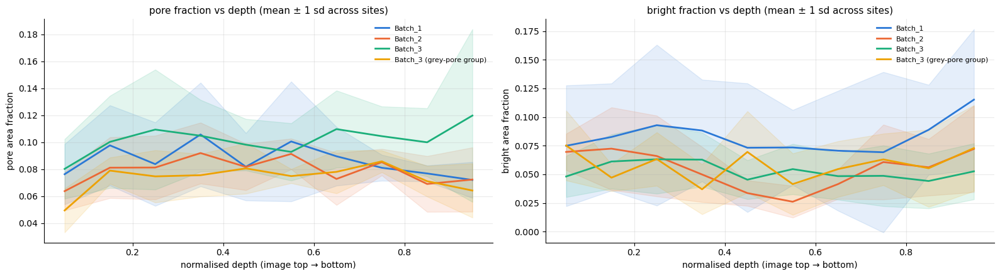

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
depth = (np.arange(10)+0.5)/10
for ax, what in zip(axes, ["pore","bright"]):
    cols = [f"profile_{what}_{k}" for k in range(10)]
    for g in groups:
        sub = F[F.group==g]; m, s = sub[cols].mean().values, sub[cols].std().values
        ax.plot(depth, m, color=COL[g], lw=2, label=g); ax.fill_between(depth, m-s, m+s, color=COL[g], alpha=.12)
    ax.set_xlabel("normalised depth (image top → bottom)"); ax.set_ylabel(f"{what} area fraction"); ax.set_title(f"{what} fraction vs depth (mean ± 1 sd across sites)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9 · Spatial texture scale (radial power spectrum)

Mean radially-averaged power spectrum of 512-px BSE patches per group. The slope reflects edge sharpness and fine texture; a shift of the curve left or right indicates coarser or finer microstructure overall — a scale-free cross-check on the segmentation-based sizes.

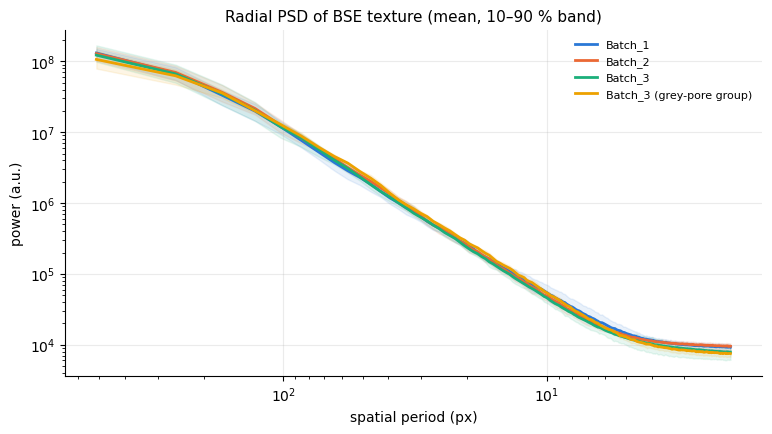

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
k = np.arange(1, 256)
for g in groups:
    keys = [f"{r.batch}/{r.site}" for _, r in F[F.group==g].iterrows()]
    S = np.array([SPEC[kk] for kk in keys]); m = S.mean(0)
    ax.plot(512/k, m, color=COL[g], lw=2, label=g)
    ax.fill_between(512/k, np.percentile(S,10,0), np.percentile(S,90,0), color=COL[g], alpha=.1)
ax.set_xscale("log"); ax.set_yscale("log"); ax.invert_xaxis(); ax.set_xlabel("spatial period (px)"); ax.set_ylabel("power (a.u.)"); ax.set_title("Radial PSD of BSE texture (mean, 10–90 % band)"); ax.legend(fontsize=8)
plt.show()

## 10 · Site-level structure: do batches separate?

Standardise the candidate KPIs, project to two principal components, and cluster. Also compute, per KPI, how much of the variance is *between* batches versus *within* (one-way ANOVA F and η²), using Batch 3 split into its two groups.

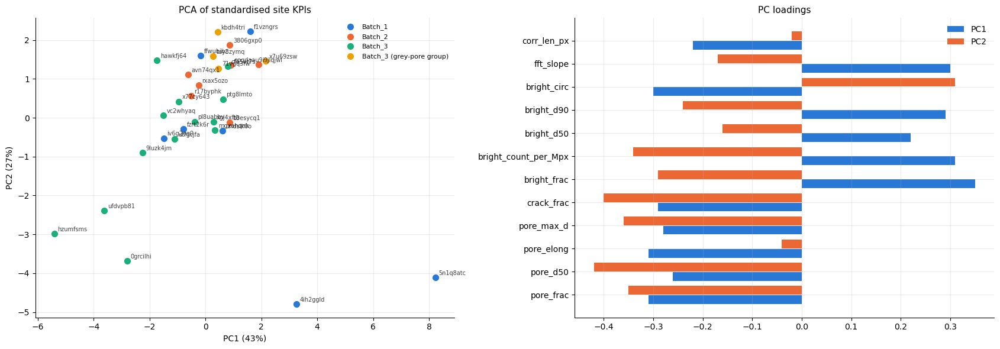

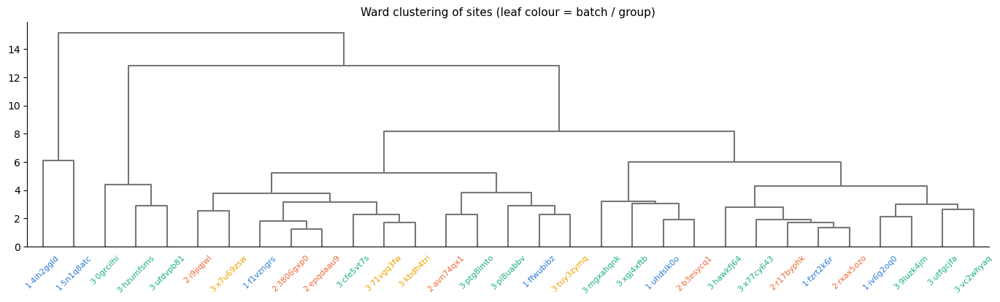

In [15]:
feat_cols = ["pore_frac","pore_d50","pore_elong","pore_max_d","crack_frac","bright_frac","bright_count_per_Mpx","bright_d50","bright_d90","bright_circ","fft_slope","corr_len_px"]
X = F[feat_cols].values; Xs = (X - X.mean(0)) / X.std(0)
U, S, Vt = np.linalg.svd(Xs - Xs.mean(0), full_matrices=False); pcs = U[:, :2] * S[:2]; expl = S**2 / (S**2).sum()
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for g in groups:
    m = (F.group==g).values; axes[0].scatter(pcs[m,0], pcs[m,1], s=50, color=COL[g], label=g, zorder=3)
for i, r in F.iterrows(): axes[0].annotate(r.site, pcs[i], fontsize=7, alpha=.75, xytext=(4,3), textcoords="offset points")
axes[0].set_xlabel(f"PC1 ({expl[0]:.0%})"); axes[0].set_ylabel(f"PC2 ({expl[1]:.0%})"); axes[0].set_title("PCA of standardised site KPIs"); axes[0].legend(fontsize=8)
load_ = pd.DataFrame(Vt[:2].T, index=feat_cols, columns=["PC1","PC2"]).round(2)
axes[1].barh(feat_cols, load_.PC1, color="#2a78d6", height=.38, label="PC1"); axes[1].barh(np.arange(len(feat_cols))+.4, load_.PC2, color="#eb6834", height=.38, label="PC2")
axes[1].set_yticks(np.arange(len(feat_cols))+.2); axes[1].set_yticklabels(feat_cols); axes[1].set_title("PC loadings"); axes[1].legend()
plt.tight_layout(); plt.show()

from scipy.cluster.hierarchy import linkage, dendrogram
Z = linkage(Xs, "ward")
fig, ax = plt.subplots(figsize=(17, 4))
dn = dendrogram(Z, labels=[f"{r.batch[-1]}·{r.site}" for _, r in F.iterrows()], ax=ax, leaf_font_size=8, color_threshold=0, above_threshold_color="#777")
for lbl in ax.get_xmajorticklabels():
    s = lbl.get_text().split("·")[1]; g = F[F.site==s].group.iloc[0]; lbl.set_color(COL[g])
ax.set_title("Ward clustering of sites (leaf colour = batch / group)"); ax.grid(False); plt.show()

In [16]:
rows = []
for k in feat_cols:
    samples = [F[F.group==g][k].values for g in groups]
    Fstat, p = stats.f_oneway(*samples)
    grand = F[k].mean(); ssb = sum(len(s)*(s.mean()-grand)**2 for s in samples); sst = ((F[k]-grand)**2).sum()
    # same test with Batch 3 kept whole, to show how much the grey-pore split matters
    s3 = [F[F.batch==b][k].values for b in BATCHES]; F3, p3 = stats.f_oneway(*s3)
    rows.append(dict(KPI=k, eta2_split=ssb/sst, F_split=Fstat, p_split=p, F_batch_only=F3, p_batch_only=p3))
sep = pd.DataFrame(rows).sort_values("eta2_split", ascending=False).round(4); display(sep)
print("η² = share of variance explained by group membership (4 groups: B1, B2, B3-ordinary, B3-grey). 'batch_only' uses the three folder labels as given.")

,KPI,eta2_split,F_split,p_split,F_batch_only,p_batch_only
0,pore_frac,0.3585,5.0291,0.0067,2.0445,0.1483
3,pore_max_d,0.3323,4.4792,0.0112,2.4476,0.1048
1,pore_d50,0.2771,3.4505,0.0304,0.5977,0.5570
4,crack_frac,0.2678,3.2909,0.0357,1.3471,0.2763
6,bright_count_per_Mpx,0.2401,2.8435,0.0564,4.3225,0.0231
11,corr_len_px,0.2363,2.7848,0.0600,1.4699,0.2471
5,bright_frac,0.2327,2.7293,0.0635,4.1509,0.0264
9,bright_circ,0.1834,2.0212,0.1346,2.8223,0.0765
7,bright_d50,0.1806,1.9842,0.1401,2.5364,0.0972
2,pore_elong,0.1713,1.8601,0.1602,1.4836,0.2441


η² = share of variance explained by group membership (4 groups: B1, B2, B3-ordinary, B3-grey). 'batch_only' uses the three folder labels as given.


**Reading §10.** The first split in the dendrogram is the two low-contrast Batch 1 sites (`4ih2ggld`, `5n1q8atc`) — an acquisition artefact, not material. The second split is the three Batch 3 sites with large delamination-like cracks (`hzumfsms`, `0grcilhi`, `ufdvpb81`) — the only candidate *material* defect signature in the data. Below those two branches, Batch 1, Batch 2 and Batch 3 sites interleave freely: on these KPIs the three folders are **not** separable as batches. The grey-pore sites sit together next to Batch 2 sites, because both have lower pore fraction and smaller pores.

The η² table says the same thing: once Batch 3 is split, pore-structure KPIs (`pore_frac`, `pore_max_d`, `pore_d50`, `crack_frac`) explain 27–36 % of between-site variance, bright-phase KPIs 18–24 % (and that mostly from the two low-contrast sites), and nothing reaches the level where a 7-site batch could be called different with confidence. Using the folder labels as given, only the bright-phase KPIs reach p < 0.05 — and those are the ones contaminated by the Batch 1 contrast problem.

## 11 · Findings

**What the dataset is**
- 31 sites × 3 detectors = 93 stitched BSE / ETD / Inlens cross-sections, ~7000 × 1600–2300 px, 8-bit. Batch 1: 7 sites, Batch 2: 7, Batch 3: 17. Porous graphite-plate coating with a sparse bright (higher-Z) additive phase; chemistry unconfirmed.
- No acquisition metadata survived. All sizes are in pixels; only relative comparisons are valid. Strip height carries no batch signal and partly fingerprints acquisition sessions.

**Acquisition is not uniform, and it matters more than batch**
1. *Contrast stretching* was applied unevenly (~half of images, strongest in Inlens). Raw gray values are not comparable between sites; every structural KPI must use per-image, histogram-anchored thresholds, and intensity statistics belong in an "instrument flags" bucket.
2. *Two Batch 1 sites* (`4ih2ggld`, `5n1q8atc`; both 2316 px tall) were recorded with the bright phase only ~25–35 gray levels above graphite instead of the usual 50–70. No threshold can separate the additive from particle rims and binder there; their bright-phase fraction and particle count come out 2–8× too high. They dominate PC1 and are the first split in the clustering. **Bright-phase KPIs for these two sites are unreliable and must be flagged, not averaged.**
3. *Four Batch 3 sites* (`71vgq3fw`, `kbdh4tri`, `tuy3zymq`, `x7u69zsw`; all 2060 px tall) have no black pixels, a grey plateau where pores should be, the lowest bright-phase separation of the normal-contrast sites (46–47 levels), and darker Inlens. This "grey-pore group" is most likely a different preparation or session (e.g. resin-filled pores). Their pore KPIs rest on a fallback threshold and read systematically low (pore fraction 0.075 vs ~0.09, pore D50 75 vs ~105 px).
4. A few images carry a thin copper or stitching band at one edge (≤ 56 rows); trimmed before measurement.

**Material structure**
- Phase fractions are stable where acquisition is normal: bright-phase area fraction 0.04–0.08 (median ≈ 0.055) in every group, bright-phase D50 ≈ 140–165 px, pore fraction 0.06–0.14. Formulation loading does not differ between batches on this evidence.
- The one clear *material* anomaly is **large, elongated crack-like voids** in three Batch 3 sites (`hzumfsms`, `0grcilhi`, `ufdvpb81`): crack-like void fraction 0.048–0.062 versus a median of 0.015–0.022 elsewhere, largest pore ⌀ 450–600 px versus ≈ 250–300 px. §6b shows them: delamination-style cracks running along the coating. They form the second split in the clustering and drive PC2.
- Batch 2 has the lowest and tightest pore fraction (0.075 ± 0.008) and the fewest crack-like voids. Batch 3 ordinary sites have a slightly longer texture correlation length (22 vs 18–19 px), i.e. marginally coarser microstructure. Both are small relative to within-batch spread.
- Through-thickness profiles show no systematic gradient in any group; the bright-phase profile of Batch 1 is wide only because of the two low-contrast sites.
- After removing the two acquisition sub-groups and the three cracked sites, the three batches are **not separable** on these KPIs: sites interleave across all three folders in PCA and clustering, and no KPI reaches a between-batch effect that 7 sites could establish with confidence.

**Implications for the QC design**
1. Build on BSE-segmentation KPIs (pore fraction and size, crack-like void fraction, largest void, bright-phase fraction / count / D50 / circularity) plus one scale-free texture descriptor. Use ETD and Inlens only for texture and edge features, never for intensity.
2. Make acquisition-quality flags first-class outputs: bright-phase separation, black level, contrast stretching, edge bands, detector label. The two biggest structures in this dataset are acquisition effects, and a QC system that cannot say "the microscope changed, not the material" will produce false rejects.
3. Calibrate every threshold against *within-baseline* spread (split-half / leave-one-site-out). With 7 sites per batch the sampling noise is large and has to be displayed, not hidden; several KPIs differ between batches by less than their within-batch standard deviation.
4. Crack-like void fraction and largest void size are the KPIs most likely to carry a real accept / investigate / reject signal; show the detected voids on the image when they drive a verdict.
5. Keep Batch 3 split until the organisers confirm what it is. If it is the baseline, the grey-pore sites and the three cracked sites must be handled explicitly (excluded, or modelled as known sub-populations), otherwise the baseline's own spread will swallow any incoming defect.

**Open questions for the organisers:** which batch is the approved baseline; whether the four grey-pore sites and the two low-contrast sites are intentional; pixel size; image orientation relative to the current collector; whether the cracked Batch 3 sites are known defects.

**Cached outputs** (reused by later notebooks): `analysis_cache/site_features.csv` (one row per site, all KPIs and quality flags), `analysis_cache/bright_particles.csv` (one row per bright-phase particle), `analysis_cache/image_quality.csv` (one row per image).